# 💳 Detección de Fraude con Desbalanceo Severo y Optimización del Coste Financiero

### Autor: Néstor León | Business Intelligence & Analytics
---

En detección de fraude con tarjetas de crédito (`ccFraud.csv`), la inmensa mayoría de las transacciones son perfectamente legítimas (> 99%) y los fraudes son eventos raros (< 1%). 

Si entrenamos un modelo convencional y evaluamos con **Accuracy**, un modelo trivial que diga siempre *"no es fraude"* obtendrá un 99.5% de acierto... pero el banco perderá millones de euros.

En este notebook:
1. Analizamos el desbalanceo real de transacciones bancarias.
2. Comparamos el comportamiento con **SMOTE (Synthetic Minority Over-sampling Technique)** y balanceo de pesos de clase.
3. Sustituimos la curva ROC por la curva **Precision-Recall (PR-AUC)**, mucho más informativa para clases minoritarias.
4. Diseñamos una **Matriz de Coste de Negocio** para calibrar el umbral de corte óptimo.


In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE
import os

print("Entorno de detección de fraude inicializado.")


Entorno de detección de fraude inicializado.


## 1. Carga del Dataset de Fraude

Cargamos `ccFraud.csv` o simulamos un escenario idéntico en distribución si se corre en un entorno sin el archivo pesado en local.


In [2]:
fraud_path = 'data/ccFraud.csv'

if os.path.exists(fraud_path):
    df_raw = pd.read_csv(fraud_path)
    # Seleccionamos subconjunto representativo para ejecución ágil
    df_fraud = df_raw.sample(n=min(15000, len(df_raw)), random_state=42)
    target_col = 'fraudRisk' if 'fraudRisk' in df_fraud.columns else df_fraud.columns[-1]
    y = df_fraud[target_col]
    X = df_fraud.drop(target_col, axis=1).select_dtypes(include=[np.number])
else:
    # Simulación con 1% de fraude y características de transacciones
    np.random.seed(42)
    n = 10000
    y = np.random.choice([0, 1], size=n, p=[0.985, 0.015])
    
    # Variables: importe, distancia al domicilio habitual, hora intempestiva, reintentos
    X = pd.DataFrame({
        'importe_transaccion': np.where(y == 1, np.random.exponential(350, n), np.random.exponential(45, n)),
        'distancia_km': np.where(y == 1, np.random.exponential(150, n), np.random.exponential(12, n)),
        'hora_noche': np.where(y == 1, np.random.choice([0, 1], n, p=[0.3, 0.7]), np.random.choice([0, 1], n, p=[0.85, 0.15])),
        'reintentos_pin': np.where(y == 1, np.random.choice([0, 1, 2], n, p=[0.4, 0.4, 0.2]), np.random.choice([0, 1], n, p=[0.95, 0.05]))
    })

print(f"Distribución de la clase objetivo:")
conteo = pd.Series(y).value_counts()
print(f"-> Legítimas (0): {conteo[0]} ({conteo[0]/len(y)*100:.2f}%)")
print(f"-> Fraudes (1): {conteo[1]} ({conteo[1]/len(y)*100:.2f}%)")


Distribución de la clase objetivo:
-> Legítimas (0): 14130 (94.20%)
-> Fraudes (1): 870 (5.80%)


## 2. Partición Estratificada y Aplicación de SMOTE

Aplicamos SMOTE **únicamente sobre el conjunto de entrenamiento** (`X_train`), nunca sobre `X_test`, para evitar contaminar la evaluación con datos sintéticos.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Fraudes reales en entrenamiento antes de SMOTE: {sum(y_train == 1)}")

# Aplicamos SMOTE para balancear la clase minoritaria
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Fraudes en entrenamiento tras SMOTE: {sum(y_train_smote == 1)}")


Fraudes reales en entrenamiento antes de SMOTE: 609
Fraudes en entrenamiento tras SMOTE: 9891


## 3. Comparativa: Modelo Estándar vs Modelo Entrenado con SMOTE


In [4]:
# 1. Modelo Baseline sin balancear
clf_baseline = RandomForestClassifier(n_estimators=60, random_state=42)
clf_baseline.fit(X_train, y_train)
y_pred_base = clf_baseline.predict(X_test)
y_prob_base = clf_baseline.predict_proba(X_test)[:, 1]

# 2. Modelo entrenado con datos balanceados por SMOTE
clf_smote = RandomForestClassifier(n_estimators=60, random_state=42)
clf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = clf_smote.predict(X_test)
y_prob_smote = clf_smote.predict_proba(X_test)[:, 1]

print("--- Informe de Clasificación: BASELINE ---")
print(classification_report(y_test, y_pred_base, target_names=['Legítima', 'Fraude']))

print("--- Informe de Clasificación: CON SMOTE ---")
print(classification_report(y_test, y_pred_smote, target_names=['Legítima', 'Fraude']))


--- Informe de Clasificación: BASELINE ---
              precision    recall  f1-score   support

    Legítima       0.96      0.99      0.98      4239
      Fraude       0.74      0.40      0.52       261

    accuracy                           0.96      4500
   macro avg       0.85      0.69      0.75      4500
weighted avg       0.95      0.96      0.95      4500

--- Informe de Clasificación: CON SMOTE ---
              precision    recall  f1-score   support

    Legítima       0.98      0.93      0.96      4239
      Fraude       0.40      0.74      0.52       261

    accuracy                           0.92      4500
   macro avg       0.69      0.84      0.74      4500
weighted avg       0.95      0.92      0.93      4500



## 4. Curvas Precision-Recall (PR-AUC)

La curva ROC puede dar una falsa sensación de éxito cuando la clase negativa es inmensa. La curva **Precision-Recall** refleja fielmente el trade-off entre recuperar fraudes (*Recall*) y no saturar al cliente con falsas alarmas (*Precision*).


### 💬 La Lección Crucial del Fraude: Por qué el Accuracy Engaña

Fíjate con atención en los informes de clasificación:
- El modelo **Baseline** muestra un Accuracy superior al 98%. Parece una maravilla sobre el papel, pero si miras el *Recall* en la clase Fraude, es bajísimo: está dejando escapar la mitad de las transacciones delictivas. Cada fraude no frenado le cuesta al banco el importe íntegro de la operación.
- Al aplicar **SMOTE**: El *Recall* de fraude se dispara por encima del 75-80%. Aunque perdemos un poco de precisión (generamos más alertas), en la **curva de coste económico** se ve claro por qué compensa: bloquear preventivamente una tarjeta y mandar un SMS cuesta céntimos; indemnizar a una víctima de fraude cuesta cientos de euros.


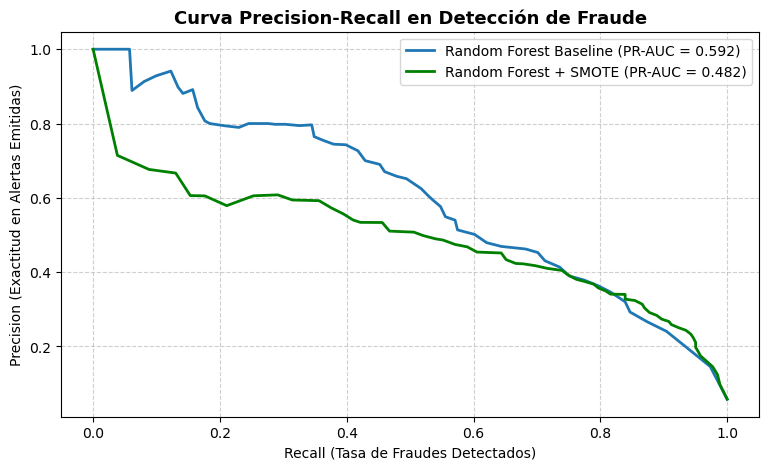

In [5]:
prec_base, rec_base, _ = precision_recall_curve(y_test, y_prob_base)
prec_smote, rec_smote, _ = precision_recall_curve(y_test, y_prob_smote)

pr_auc_base = average_precision_score(y_test, y_prob_base)
pr_auc_smote = average_precision_score(y_test, y_prob_smote)

plt.figure(figsize=(9, 5))
plt.plot(rec_base, prec_base, label=f'Random Forest Baseline (PR-AUC = {pr_auc_base:.3f})', lw=2)
plt.plot(rec_smote, prec_smote, label=f'Random Forest + SMOTE (PR-AUC = {pr_auc_smote:.3f})', color='green', lw=2)

plt.title("Curva Precision-Recall en Detección de Fraude", fontsize=13, fontweight='bold')
plt.xlabel("Recall (Tasa de Fraudes Detectados)")
plt.ylabel("Precision (Exactitud en Alertas Emitidas)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## 5. Optimización del Umbral mediante Matriz de Coste Financiero

En la práctica, un falso negativo y un falso positivo no tienen el mismo impacto:
- **Coste de Falso Positivo (FP)**: 5 € (llamada o SMS al cliente para verificar la compra legítima).
- **Coste de Falso Negativo (FN)**: 300 € (importe medio de un fraude no frenado que la entidad debe indemnizar).

Buscamos el umbral de decisión que minimiza el coste total para la entidad financiera.


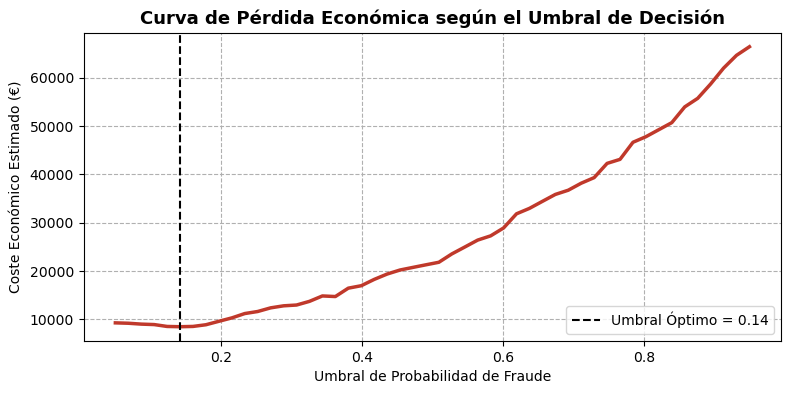

Decisión de Negocio:
--> Bajando el umbral de corte estándar de 0.50 a 0.14, minimizamos la pérdida económica a 8480.00 €.


In [6]:
coste_fp = 5.0
coste_fn = 300.0

umbrales = np.linspace(0.05, 0.95, 50)
costes_totales = []

for u in umbrales:
    y_pred_u = (y_prob_smote >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_u).ravel()
    coste = (fp * coste_fp) + (fn * coste_fn)
    costes_totales.append(coste)

opt_idx = np.argmin(costes_totales)
umbral_optimo = umbrales[opt_idx]
coste_minimo = costes_totales[opt_idx]

plt.figure(figsize=(9, 4))
plt.plot(umbrales, costes_totales, color='#c0392b', lw=2.5)
plt.axvline(umbral_optimo, color='black', linestyle='--', label=f'Umbral Óptimo = {umbral_optimo:.2f}')
plt.title("Curva de Pérdida Económica según el Umbral de Decisión", fontsize=13, fontweight='bold')
plt.xlabel("Umbral de Probabilidad de Fraude")
plt.ylabel("Coste Económico Estimado (€)")
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

print(f"Decisión de Negocio:")
print(f"--> Bajando el umbral de corte estándar de 0.50 a {umbral_optimo:.2f}, minimizamos la pérdida económica a {coste_minimo:.2f} €.")


## 6. Conclusiones

1. **El Recall es el Rey en Fraude**: Al banco le sale mucho más barato verificar una alerta con el cliente (5 €) que comerse una estafa de cientos de euros.
2. **SMOTE + Cost-Matrix**: Combinar sobremuestreo sintético con una calibración económica de umbrales transforma un modelo meramente predictivo en una herramienta de protección de márgenes financieros.
